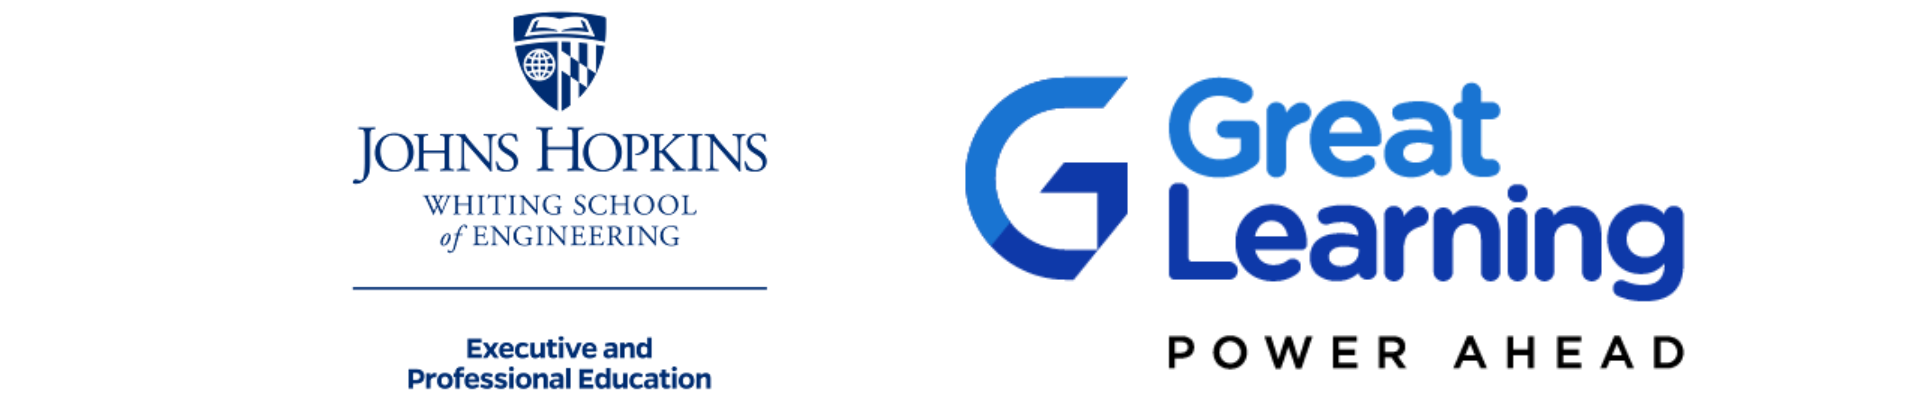

<center><font size=1</font></center>
<center><font size=6>MLS 4 - Prompt Optimisation and Evaluation</font></center>

# 1. Problem Statement

## Business Context

NovaTech is a mid-sized consumer electronics company that sells smartphones, laptops, headphones, and smartwatches. It operates in the US, Canada, and the UK, and manages a portfolio of 34 active SKUs across multiple product categories.

The Product team at NovaTech is made up of six Product Managers (PMs). These PMs rely on customer reviews to understand user experiences, identify product issues, and prioritise future improvements. With over 8,000 customer reviews generated every week across the catalogue, manually analysing and categorising feedback has become a heavy operation, requiring approximately **306 hours of PM effort per quarter**. That is time the team cannot spend on product strategy and roadmap planning.

To improve efficiency, NovaTech is exploring AI-powered review summarisation. The catch is that reducing manual effort alone is not enough. If the AI summaries are inaccurate, incomplete, or misleading, the PMs will make poor product decisions on the back of them, which is worse than the manual effort we set out to save.

Four risks need to be addressed before an AI summarisation pipeline can be trusted:

- **Faithfulness risk.** Summaries must accurately represent information present in customer reviews. Introducing unsupported claims, exaggerating issues, or attributing feedback that customers did not provide will lead to an incorrect understanding of customer needs.

- **Sentiment interpretation risk.** Summaries should reflect the overall distribution of customer sentiment. If most customers are positive, the summary should say so while still highlighting important concerns. When customers have mixed opinions, the summary should preserve both perspectives rather than averaging them into a neutral middle.

- **Actionability risk.** PMs need summaries they can act on. A useful summary highlights specific complaints, feature requests, and improvement areas. Generic observations force the PM to read the source reviews anyway, which defeats the purpose.

- **Completeness risk.** Summaries should capture the important themes present in customer feedback, including major complaints, feature requests, and standout positive experiences. Missing key feedback or over-generalising specific issues means teams overlook real customer pain points.

NovaTech therefore needs an evaluated summarisation pipeline that saves the 306 hours of PM effort per quarter while guarding against all four risks before any summary reaches a decision maker.

## Objective

The objective is to build an **evaluated summarisation pipeline** that turns raw customer reviews into short, structured, verified summaries that PMs can act on directly, and to demonstrate with numbers that each successive improvement in the pipeline earns its added complexity.

The pipeline routes every summary through a scoring stage, then to one of three actions:

1. **Auto approve.** The summary is trustworthy enough to file a Jira ticket automatically.
2. **Human review.** The summary is mostly good but one metric fell below threshold; a PM checks it before acting.
3. **Reject.** The summary failed a safety threshold and is not propagated downstream.

#2. Success Criteria

| Business objective | Technical metric | Type | Threshold | Rationale |
|---|---|---|---|---|
| Save PM review time | % SKUs auto approved | Efficiency metric | at least 60% | Operational automation target. Below 60%, the savings are too small to justify the pipeline. Above 60%, the 306-hour quarterly workload is meaningfully reduced. |
| Avoid reputational damage | Faithfulness score | Faithfulness (GEval) | at least 0.80 | Faithfulness measures whether generated summaries are grounded in the original reviews and do not introduce unsupported claims. Higher faithfulness correlates with human factuality judgement per MiniCheck (Tang et al., EMNLP 2024). |
| Ship the correct product fix | Completeness score | Completeness (GEval) | at least 0.70 | Completeness measures whether summaries capture the important themes in customer feedback. The 0.70 threshold aligns with key-fact recall protocols used by FineSurE and similar summary evaluation frameworks, where roughly 70% coverage is treated as an acceptable baseline for decision-support summaries. |
| Ship the correct product fix | Actionability score | Actionability (GEval) | at least 0.70 | No universal industry benchmark exists for actionability. The threshold is calibrated against PM review criteria using the gold test set: a specific complaint counts; a generic phrase like "quality concerns" does not. |
| Represent customer voice fairly | Sentiment balance score | Sentiment Balance (GEval) | at least 0.70 | Calibrated against human-labelled sentiment distributions in the gold set. A summary that softens a genuinely angry review base or amplifies a small complaint fails this metric. |
| Guard against summary drift | ROUGE-L overlap with source | ROUGE-L | at least 0.15 | Deterministic lexical-overlap check that catches summaries that drift away from the source reviews entirely. Typical range for abstractive summarisation is 0.15 to 0.30; too low means the model is not grounding in the reviews, too high means it is copying. |
| Scale cost effectively | Average cost per summary | Cost metric | at most $0.01 | Based on expected inference economics of a small model like gpt-4o-mini and the volume constraint (34 SKUs, weekly cadence). |
| Scale cost effectively | p95 latency | Latency metric | at most 3 seconds | Standard production service-level objective for interactive PM workflows. p95 rather than mean, because tail latency is what breaks the user experience. |

#3. Solution Approach

The pipeline is built in four measurable phases, and every phase is scored against the same evaluation setup so improvements can be compared directly.

1. **Define the evaluation setup first.** Before any generation code is written, define the summary schema, the four quality metrics (faithfulness, sentiment balance, actionability, completeness), a deterministic ROUGE-L check, and a comparison function. Every subsequent phase is scored against this same setup so results are directly comparable.

2. **Naive baseline (v0).** Ask the model for a short generic summary with no schema and no rules. This mirrors what a PM would get by pasting reviews into a chat interface today. Its scores define the gap that later phases must close.

3. **Zero-shot structured prompt (v1).** Add a business-appropriate persona, explicit grounding rules, and a Pydantic schema enforced at the token level. The schema forces the model to enumerate complaints, positives, and feature requests as separate list fields instead of collapsing them into prose.

4. **Few-shot structured prompt (v2).** Add three pre-authored examples that cover the failure modes v1 is most likely to hit: over-generalising specific complaints, inventing complaints on genuinely positive products, and averaging polarised sentiment into a bland middle.

5. **GEPA-optimised prompt (v3).** Use the GEPA (Genetic Pareto) optimiser to evolve v2 automatically against the four quality metrics. GEPA generates mutation candidates, scores each against the same setup, and keeps the Pareto-optimal ones.

Each phase is scored on a **gold tuning set** in a final generalisation check, on a **held-out test set** that was never touched during prompt development. Every version's scores are reported as mean and standard deviation across independent runs. The winning version is deployed behind a **confidence-gate router** that routes each summary to auto-approve, human review, or reject based on the four scores. Cost and latency are tracked throughout so the technical wins can be translated into a business recommendation.

## Why use an OpenAI LLM here?

A fair question. Encoder-decoder models such as BART, PEGASUS, and T5 were purpose-built for summarisation and often match or beat decoder-only LLMs on cost. There are two reasons an LLM is still the right choice here.

**First**, the pipeline requires **structured JSON output** with per-summary sentiment, complaints, and feature requests as separate fields. Getting that from a fine-tuned BART needs additional engineering (post-processing, separate classifiers, or one fine-tuning pass per field). An LLM with a Pydantic schema returns it in a single call.

**Second**, the downstream evaluation (PM utility scoring, hallucination flags, confidence gates) **generalises across generators**. Once the evaluation setup is in place, swapping the generator for a fine-tuned BART is a one-cell change. So even if NovaTech later moves to a smaller model for cost reasons, everything else in this notebook remains reusable.

# 4. Setup

### 4.1 Install dependencies

In [ ]:
# Install the exact library versions this notebook was built against.
# Pinning versions keeps results reproducible across machines and reruns.

!pip install openai==2.50.0 deepeval==4.2.2 pydantic==2.13.4 scipy==1.18.0 pyyaml==6.0.3 rouge-score==0.1.2 pandas==2.2.3 matplotlib==3.10.0 nest_asyncio==1.6.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.4 MB/s eta 0:00:00


**Note:**

After running the above cell, restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), then run all cells sequentially from the next cell. On executing the install line you may see a warning about package dependencies. The warning can be ignored: the pinned versions above are all that is required to run this notebook.

### 4.2 Imports

In [ ]:
# Standard library
import os
import json
import time
import random
import asyncio
from datetime import datetime
from pathlib import Path
from typing import Literal, Union
import nest_asyncio
nest_asyncio.apply()

# Data and numeric
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

# LLM and schema. Two clients: one for single calls, one for parallel loops.
from openai import OpenAI, AsyncOpenAI
from pydantic import BaseModel, Field

os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "180"

# DeepEval building blocks used in this notebook
from deepeval.prompt import Prompt
from deepeval.dataset import Golden
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.optimizer.configs import AsyncConfig, DisplayConfig
from deepeval.optimizer import PromptOptimizer
from deepeval.optimizer.algorithms import GEPA
from deepeval.models import OpenAIModel
from deepeval.metrics import utils as deepeval_metric_utils

# Deterministic lexical-overlap metric used alongside the LLM-scored metrics
from rouge_score import rouge_scorer

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

/tmp/ipykernel_41987/1440714911.py:29: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams
/tmp/ipykernel_41987/1440714911.py:33: DeprecationWarning: 'GPTModel' is deprecated and will be removed in a future release. Use 'OpenAIModel' instead.
  from deepeval.models import GPTModel,OpenAIModel


**Note:** If you encounter a rate limit error from OpenAI in any of the code cells, it is likely due to high server load at that time. Wait for 2-3 minutes, then re-run the last executed cell. The request should succeed once the server load decreases.

### 4.3 Global constants

A note on determinism: OpenAI's `seed` parameter is best effort, not guaranteed. Same seed plus same parameters plus same `system_fingerprint` gives mostly identical outputs, but a small fraction of calls will differ across identical runs. That is why this notebook reports mean and standard deviation across N runs, not a single point estimate.

In [ ]:
# Reproducibility
SEED = 42

# Temperature. Fixed at 0.1 for both generation and judging.
TEMPERATURE = 0.1

# Model roles. A cheaper model for generation, a stronger model for judging.
GENERATOR_MODEL = 'gpt-4o-mini'
JUDGE_MODEL = 'gpt-4o'

# Number of independent runs per experiment. Two is enough for the demo scale.
N_RUNS = 2

# Async concurrency ceiling. Keeps the proxy from being overloaded.
CONCURRENCY = 2

# Folders written to disk by the notebook itself.
PROMPTS_DIR = Path('prompts')
RAW_DIR = Path('raw_responses')

# Pricing (USD per 1M tokens). Verify current rates before quoting to leadership.
PRICING = {
    'gpt-4o-mini': {'input': 0.15, 'output': 0.60},
    'gpt-4o':      {'input': 2.50, 'output': 10.00},
}

# Assumptions used by the business dashboard.
PM_HOURLY_COST_USD = 50
MANUAL_REVIEW_MIN_PER_SKU = 20

### 4.4 OpenAI Clients

There are two ways to spin up an OpenAI client:

- `sync` (synchronous): for one-off calls.
- `async` (asynchronous): for large-scale experimentation loops with parallel execution.

Both modes are needed later, and both are created below.

**Note:** Before running the next cell, upload the `config.json` file to Colab.

In [ ]:
# Load API credentials
with open("config.json", "r") as f:
    config = json.load(f)

OPENAI_API_KEY = config["OPENAI_API_KEY"]
OPENAI_BASE_URL = config["OPENAI_BASE_URL"]

# Make them available to libraries such as DeepEval
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
os.environ["OPENAI_BASE_URL"] = OPENAI_BASE_URL

# Regular OpenAI clients used by this notebook
client = OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
)

async_client = AsyncOpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
)

print("OpenAI clients ready.")
print("Base URL:", OPENAI_BASE_URL)
print("API key loaded:", bool(OPENAI_API_KEY))

OpenAI clients ready.
Base URL: https://aibe.mygreatlearning.com/openai/v1
API key loaded: True


# 5. Data Loading

Two datasets are used:

- **`gold_reviews.csv`** (15 products). The tuning set. Every prompt version is scored against this set.
- **`test_reviews.csv`** (5 products). A held-out generalisation set with the same schema, used only in the final phase to check whether the winning prompt overfits the tuning set.

Each row is one product with columns: `product_id`, `product_name`, `category`, `total_reviews`, `avg_rating`, `test_case_type`, `edge_case_description`, `reviews_text`. The `reviews_text` column holds all reviews for that product concatenated with `|` as the separator, each review prefixed with `Review N (X stars):`.

The gold set spans multiple product categories and covers a mix of test-case types: three baseline patterns (mixed sentiment at medium, below average, and above average ratings) plus a set of edge cases such as all 5-star, almost all 1-star, sparse data, conflicting reviews, a hallucination trap, and safety complaints. This keeps the tuning set small enough to run quickly while still stress-testing each business risk.

In [ ]:
# Load the two review corpora from disk.
# gold = the tuning set every prompt version is scored on.
# test = the held-out set used only in the final generalisation check.

GOLD_PATH = 'gold_reviews.csv'
TEST_PATH = 'test_reviews.csv'

gold_dataset = pd.read_csv(GOLD_PATH)
test_dataset = pd.read_csv(TEST_PATH)

# Confirm both files loaded with the row and column counts expected.
print(f'Gold dataset: {gold_dataset.shape[0]} products, {gold_dataset.shape[1]} columns')
print(f'Test dataset: {test_dataset.shape[0]} products, {test_dataset.shape[1]} columns')
print()
print('Test case type distribution in gold set:')
print(gold_dataset['test_case_type'].value_counts().to_string())

Gold dataset: 15 products, 8 columns
Test dataset: 5 products, 8 columns

Test case type distribution in gold set:
test_case_type
BASELINE - mixed sentiment, medium rating                                 2
BASELINE - mixed sentiment, below average rating                          2
BASELINE - mostly positive, above average rating                          2
EDGE CASE - all 5-star reviews, unanimously positive                      1
EDGE CASE - almost all 1-star reviews, product failure                    1
EDGE CASE - very few reviews (only 3), sparse data                        1
EDGE CASE - highly conflicting reviews, same features rated oppositely    1
EDGE CASE - hallucination trap with vague reviews                         1
EDGE CASE - safety complaints in reviews, tests safety metric             1
EDGE CASE - one complaint dominates all reviews                           1
EDGE CASE - accessory product with minimal feedback, simple reviews       1
EDGE CASE - very long detailed rev

### 5.1 Preview one record

Each row of the dataset is one product with all its reviews concatenated into a single field.

In [ ]:
gold_dataset.head()

,product_id,product_name,category,total_reviews,avg_rating,test_case_type,edge_case_description,reviews_text
0,G001,NovaTech PowerBand Gen1,Smartwatches,8,3.75,"BASELINE - mixed sentiment, medium rating",Normal mixed product with typical baseline patterns.,"Review 1 (5 stars): Design feels premium and comfortable on the wrist all day. | Review 2 (4 stars): GPS tracking is pinpoint accurate for running and cycling. | Review 3 (4 stars): Companion app is intuitive and well organised. Only downside is heart rate monitoring is inconsistent during high intensity exercise. | Review 4 (3 stars): Design feels premium and comfortable on the wrist all day. However, strap material irritates skin during workouts and gets sweaty quickly. | Review 5 (2 stars): Voice assistant is slow to respond and often mishears commands. | Review 6 (4 stars): Sleep tracking gives genuinely useful morning insights. | Review 7 (3 stars): Haptic feedback is precise and unobtrusive for notifications. However, gps takes over a minute to lock, frustrating for quick workouts. | Review 8 (5 stars): Battery lasts a full week on a single charge with GPS use."
1,G013,NovaTech PowerBand Gen3,Smartwatches,8,3.75,"BASELINE - mixed sentiment, medium rating",Normal mixed product with typical baseline patterns.,"Review 1 (5 stars): GPS tracking is pinpoint accurate for running and cycling. | Review 2 (4 stars): Sleep tracking gives genuinely useful morning insights. | Review 3 (4 stars): Design feels premium and comfortable on the wrist all day. Only downside is voice assistant is slow to respond and often mishears commands. | Review 4 (3 stars): GPS tracking is pinpoint accurate for running and cycling. However, case scratches easily and looks worn after a couple of months. | Review 5 (2 stars): Strap material irritates skin during workouts and gets sweaty quickly. | Review 6 (4 stars): Companion app is intuitive and well organised. | Review 7 (3 stars): Health tracking is remarkably accurate, matches clinical readings. However, gps takes over a minute to lock, frustrating for quick workouts. | Review 8 (5 stars): Battery lasts a full week on a single charge with GPS use."
2,G002,NovaTech MirrorLite 5 Gen1,Cameras,7,3.29,"BASELINE - mixed sentiment, below average rating",Normal mixed product with performance inconsistency.,"Review 1 (4 stars): Menu system is intuitive and quick to navigate. Only downside is menu system takes weeks to learn and is not intuitive. | Review 2 (2 stars): Autofocus hunts in low light despite the marketing. | Review 3 (3 stars): Autofocus is fast and accurate even in low light. However, buffer fills quickly and slows down burst shooting. | Review 4 (5 stars): Video autofocus tracking is smooth and reliable. | Review 5 (1 stars): Bluetooth connection to the app drops constantly. | Review 6 (4 stars): Battery lasts an entire day of moderate shooting. | Review 7 (4 stars): Weight is manageable for travel and street photography. Only downside is grip is uncomfortable for extended sessions with a longer lens."
3,G014,NovaTech MirrorLite 5 Gen3,Cameras,7,3.29,"BASELINE - mixed sentiment, below average rating",Normal mixed product with performance inconsistency.,"Review 1 (4 stars): Image quality rivals cameras costing twice as much. Only downside is buffer fills quickly and slows down burst shooting. | Review 2 (2 stars): Autofocus hunts in low light despite the marketing. | Review 3 (3 stars): Weather sealing has held up in rain and dust. However, low light noise is worse than expected at higher isos. | Review 4 (5 stars): Menu system is intuitive and quick to navigate. | Review 5 (1 stars): Menu system takes weeks to learn and is not intuitive. | Review 6 (4 stars): Video autofocus tracking is smooth and reliable. | Review 7 (4 stars): Weight is manageable for travel and street photography. Only downside is battery life is disappointing, spare batteries are essential."
4,G003,NovaTech AirBook Gen1,Laptops,9,4.00,"BASELINE - mostly positive, above a

The row above is compact. A more readable view of the first record is shown below.

In [ ]:
# Print one full record to see the exact schema each row carries
# before building anything on top of it.

sample = gold_dataset.iloc[0]
print(f"Product ID    : {sample['product_id']}")
print(f"Product Name  : {sample['product_name']}")
print(f"Category      : {sample['category']}")
print(f"Total Reviews : {sample['total_reviews']}")
print(f"Avg Rating    : {sample['avg_rating']} / 5")
print(f"Edge Case Tag : {sample['test_case_type']}")
print(f"Edge Case Desc: {sample['edge_case_description']}")
print(f"\nFirst 500 chars of reviews_text:")
print(sample['reviews_text'][:500] + '...')

Product ID    : G001
Product Name  : NovaTech PowerBand Gen1
Category      : Smartwatches
Total Reviews : 8
Avg Rating    : 3.75 / 5
Edge Case Tag : BASELINE - mixed sentiment, medium rating
Edge Case Desc: Normal mixed product with typical baseline patterns.

First 500 chars of reviews_text:
Review 1 (5 stars): Design feels premium and comfortable on the wrist all day. | Review 2 (4 stars): GPS tracking is pinpoint accurate for running and cycling. | Review 3 (4 stars): Companion app is intuitive and well organised. Only downside is heart rate monitoring is inconsistent during high intensity exercise. | Review 4 (3 stars): Design feels premium and comfortable on the wrist all day. However, strap material irritates skin during workouts and gets sweaty quickly. | Review 5 (2 stars): V...


# 6. Evaluation Setup

The evaluation setup is defined before any generation code is written. This way each subsequent phase can be scored against the same setup and improvements can be compared directly. If metrics were defined only later, it would not be possible to state clearly what gap each phase set out to close.

The setup has six parts:

1. A **Pydantic schema** that pins the shape of every generated summary.
2. **Four GEval metrics** that map one-to-one to the four business risks in Section 1.
3. A **ROUGE-L check** that provides a deterministic lexical-overlap score alongside the LLM-scored metrics.
4. A **Golden dataset** wrapping the review corpus so DeepEval and GEPA can consume it.
5. A **`format_full_output` helper** that turns a structured summary into a single string the judge sees.
6. A **`score_one` function** that runs every metric on one summary and returns a dictionary of scores.

### 6.1 Pydantic schema for the summary output

OpenAI's structured-outputs mode enforces this schema at the token level, so parsing failures cannot happen by construction. That is the reason for using Pydantic here rather than prompting for JSON and then parsing the response with regular expressions.

| Attribute | Type | Why |
|---|---|---|
| `summary` | str | A 2-3 sentence balanced summary grounded in the source reviews. |
| `top_positives` | list[str] | Specific positives named by reviewers (2-4 items when supported by the reviews). |
| `top_complaints` | list[str] | Specific complaints named by reviewers (2-4 items when supported by the reviews). |
| `feature_requests` | list[str] | Specific improvements customers explicitly asked for. |
| `overall_sentiment` | Literal | Fixed sentiment label: `Positive`, `Neutral`, or `Negative`. |

In [ ]:
# Pydantic schema that pins the shape of every generated summary.
# OpenAI's structured-outputs mode enforces this at the token level, so
# a summary can never come back missing a field or in the wrong type.

class ProductSummary(BaseModel):
    summary: str = Field(description="2-3 sentence balanced summary grounded in the source reviews.")
    top_positives: list[str] = Field(description="2-4 specific positives mentioned in reviews.")
    top_complaints: list[str] = Field(description="2-4 specific complaints mentioned in reviews.")
    feature_requests: list[str] = Field(description="Specific improvements customers explicitly asked for.")
    overall_sentiment: Literal["Positive", "Neutral", "Negative"]

### 6.2 The four GEval metrics

Each metric is scored by an LLM judge against a rubric written below, on the 0.0 to 1.0 scale. The judge is `gpt-4o` (stronger than the generator) for two reasons: it reduces the self-preference bias where a model tends to score its own outputs higher, and a stronger judge catches errors a weaker one would miss. Cost impact is small because judge calls are far fewer and much shorter than generation calls.

In [ ]:
judge_model = OpenAIModel(
    model=JUDGE_MODEL,
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
    temperature=TEMPERATURE,
)

In [ ]:
judge_model.generate('Hi')

('Hello! How can I assist you today?', 0.00011)

In [ ]:
# Four LLM-as-judge metrics, one per business risk from Section 1.
# Each carries the rubric the judge scores against plus the pass threshold
# from the success-criteria table in Section 2.

faithfulness_metric = GEval(
    name="Faithfulness",
    criteria=(
        "Evaluate whether every claim in the summary is explicitly supported by "
        "the provided customer reviews (context). Penalise any claim that cannot "
        "be traced directly to the source reviews. Award full marks only when "
        "all claims are unambiguously grounded in the reviews."
    ),
    evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.CONTEXT],
    model=judge_model,
    threshold=0.8,
    async_mode=False
)

sentiment_balance_metric = GEval(
    name="SentimentBalance",
    criteria=(
        "Assess whether the summary's tone reflects the distribution of ratings "
        "in the source reviews. If most reviews are 4-5 stars, the summary should "
        "be positive. If reviewers disagree, the summary must preserve both sides "
        "rather than average them into a neutral middle. Penalise summaries that "
        "soften or overstate the actual sentiment distribution."
    ),
    evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.CONTEXT],
    model=judge_model,
    threshold=0.7,
    async_mode=False
)

actionability_metric = GEval(
    name="Actionability",
    criteria=(
        "Assess whether a Product Manager could take a concrete decision from this "
        "summary alone, without re-reading the source reviews. Look for specific "
        "complaints (not 'quality concerns'), specific feature requests (not 'wants "
        "improvements'), and clear signals about what to fix next. Penalise generic "
        "observations that force the PM to read the raw reviews to figure out what to do."
    ),
    evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT],
    model=judge_model,
    threshold=0.7,
    async_mode=False
)

completeness_metric = GEval(
    name="Completeness",
    criteria=(
        "Check whether every distinct complaint, feature request, or notable positive "
        "in the source reviews (context) appears in the summary. Penalise cases where "
        "a specific complaint has been over-generalised (for example, 'charging brick "
        "does not fit' collapsed to 'battery concerns') or dropped entirely."
    ),
    evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.CONTEXT],
    model=judge_model,
    threshold=0.7,
    async_mode=False
)

HARNESS_METRICS = [
    faithfulness_metric,
    sentiment_balance_metric,
    actionability_metric,
    completeness_metric,
]

print(f"Setup ready: {len(HARNESS_METRICS)} LLM-scored metrics")
for m in HARNESS_METRICS:
    print(f"  {m.name} (threshold: {m.threshold})")

Setup ready: 4 LLM-scored metrics
  Faithfulness (threshold: 0.8)
  SentimentBalance (threshold: 0.7)
  Actionability (threshold: 0.7)
  Completeness (threshold: 0.7)


### 6.3 ROUGE-L deterministic check

The four GEval metrics capture subjective quality (does the summary read well, is it useful for a PM, does it feel balanced). ROUGE-L captures **lexical overlap** with the source reviews. Adding a deterministic metric alongside the LLM judges catches gross summary-versus-source drift that LLM judges sometimes miss. Typical ROUGE-L values for abstractive summarisation fall in the 0.15 to 0.30 range: too low means the summary is not grounded in the reviews, too high means the model is copying rather than summarising.

In [ ]:
# ROUGE-L scorer. Deterministic, cheap, and complements the LLM-scored metrics
# by catching cases where the summary drifts too far from the source reviews.

_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def rouge_l(summary_text: str, source_text: str) -> float:
    """Return ROUGE-L f-measure between a generated summary and the source reviews."""
    return _rouge.score(source_text, summary_text)['rougeL'].fmeasure

print('ROUGE-L scorer ready (threshold: 0.15).')

ROUGE-L scorer ready (threshold: 0.15).


### 6.4 Build the Golden dataset

The Golden dataset converts each row of a review DataFrame into a DeepEval `Golden` object. Goldens are the test cases that GEPA optimises against and that the scoring loops iterate over. Building them once here means every subsequent phase reuses the same test set with no drift.

In [ ]:
def build_goldens(dataset: pd.DataFrame) -> list[Golden]:
    """Convert a dataset DataFrame into a list of DeepEval Goldens."""
    goldens = []
    for _, row in dataset.iterrows():
        input_str = (
            f"Product Name: {row['product_name']}\n"
            f"Category: {row['category']}\n"
            f"Total Reviews: {row['total_reviews']}\n"
            f"Average Rating: {row['avg_rating']} / 5\n\n"
            f"Reviews:\n{row['reviews_text']}"
        )
        goldens.append(Golden(
            input=input_str,
            context=[row["reviews_text"]],
            additional_metadata={"product_id": row["product_id"],
                                 "product_name": row["product_name"]},
        ))
    return goldens

gold_goldens = build_goldens(gold_dataset)
test_goldens = build_goldens(test_dataset)

print(f"Gold goldens: {len(gold_goldens)}")
print(f"Test goldens: {len(test_goldens)}")

Gold goldens: 15
Test goldens: 5


### 6.5 Serialise the structured output for scoring

**This helper is what makes structured outputs actually show their value.**

If the judge only sees `summary_obj.summary` (the 2-3 sentence text field), it never sees the specifics that live in `top_complaints`, `top_positives`, and `feature_requests`. Structured versions would then look artificially weak because the specific content moved out of the summary paragraph and into the arrays where the judge cannot see it.

`format_full_output` flattens the structured object into a single string that includes all fields, so the judge sees exactly what the PM sees. Naive plain-text summaries are returned unchanged.

In [ ]:
def format_full_output(summary_obj: Union[ProductSummary, str]) -> str:
    """Serialise a structured ProductSummary into a single string for the judge.

    Naive text outputs are returned as is. Structured outputs are flattened into
    a header + bullet list layout so the judge sees every field the PM will see.
    """
    if isinstance(summary_obj, str):
        return summary_obj

    parts = [f"Summary: {summary_obj.summary}"]
    if summary_obj.top_positives:
        parts.append("Top positives:\n" +
                     "\n".join(f"- {p}" for p in summary_obj.top_positives))
    if summary_obj.top_complaints:
        parts.append("Top complaints:\n" +
                     "\n".join(f"- {c}" for c in summary_obj.top_complaints))
    if summary_obj.feature_requests:
        parts.append("Feature requests:\n" +
                     "\n".join(f"- {r}" for r in summary_obj.feature_requests))
    parts.append(f"Overall sentiment: {summary_obj.overall_sentiment}")
    return "\n\n".join(parts)

### 6.6 Score one summary against every metric

`score_one` wraps the `(input, actual_output, context)` triple in an `LLMTestCase`, calls each GEval metric's `measure` method, computes ROUGE-L against the source reviews, and returns a dictionary of scores. Every scored summary is fed the same fully serialised artefact from `format_full_output`.

In [ ]:
def score_one(golden: Golden, actual_output: str) -> dict:
    """Score one serialised summary against every metric. Synchronous."""
    test_case = LLMTestCase(
        input=golden.input,
        actual_output=actual_output,
        context=golden.context,
    )
    scores = {}
    # LLM-scored metrics
    for metric in HARNESS_METRICS:
        try:
            metric.measure(test_case)
            scores[metric.name.lower()] = metric.score if metric.score is not None else 0.0
        except Exception as e:
            print(f'  {metric.name} failed: {e}')
            scores[metric.name.lower()] = 0.0
    # Deterministic ROUGE-L against the source reviews
    try:
        source_text = golden.context[0] if golden.context else ''
        scores['rouge_l'] = round(rouge_l(actual_output, source_text), 4)
    except Exception as e:
        print(f'  ROUGE-L failed: {e}')
        scores['rouge_l'] = 0.0
    return scores


async def score_one_async(golden: Golden, actual_output: str) -> dict:
    """Run scoring synchronously to avoid DeepEval's async OpenAIModel path."""
    return score_one(golden, actual_output)

# 7. Utility Functions

This section contains the three helpers the rest of the notebook depends on. `llm_call` (and its async twin) wraps every LLM request so all the reproducibility instrumentation lives in one place. `run_experiment` runs one prompt version across N runs in parallel and appends the scores to a global DataFrame. `compare_experiments` compares two versions and reports mean and standard deviation per metric.

The async plumbing exists purely for speed: scoring 60 products by 2 runs by 5 metrics one at a time would take about an hour; with a concurrency cap it drops to a few minutes. When reading top to bottom, treat these three names as a black box. The later experiment cells just call `run_experiment("v1_zero_shot", ...)` and never touch async themselves.

### 7.1 LLM call wrapper with per-call instrumentation

One place to add reproducibility instrumentation (seed, `system_fingerprint`, latency logging), one place to swap providers later, one place to add retry logic. Every LLM call in the notebook goes through this wrapper.

In [ ]:
# Global run log. Every llm_call (sync or async) appends one row.
# Used by the cost and latency summary at the end of the notebook.
run_log = []
RAW_DIR.mkdir(exist_ok=True)


def _log_row(tag, model, temperature, seed, resp, latency_ms):
    run_log.append({
        'timestamp': datetime.utcnow().isoformat(),
        'tag': tag,
        'model': model,
        'temperature': temperature,
        'seed': seed,
        'prompt_tokens': resp.usage.prompt_tokens,
        'completion_tokens': resp.usage.completion_tokens,
        'system_fingerprint': resp.system_fingerprint,
        'latency_ms': round(latency_ms, 1),
    })


def llm_call(system_prompt, user_prompt, model=None, temperature=None,
             seed=None, response_schema=None, tag=''):
    """Synchronous single call. Used for one-off calls and the GEPA callback."""
    model = model or GENERATOR_MODEL
    temperature = temperature if temperature is not None else TEMPERATURE
    seed = seed if seed is not None else SEED

    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': user_prompt},
    ]

    t0 = time.perf_counter()

    if response_schema is not None:
        resp = client.chat.completions.parse(
            model=model,
            messages=messages,
            temperature=temperature,
            seed=seed,
            response_format=response_schema,
        )
        content = resp.choices[0].message.parsed
    else:
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            seed=seed,
        )
        content = resp.choices[0].message.content
    latency_ms = (time.perf_counter() - t0) * 1000
    _log_row(tag, model, temperature, seed, resp, latency_ms)
    return content


async def llm_call_async(system_prompt, user_prompt, model=None, temperature=None,
                         seed=None, response_schema=None, tag=''):
    """Async version of llm_call. Same interface, non-blocking on the network wait."""
    model = model or GENERATOR_MODEL
    temperature = temperature if temperature is not None else TEMPERATURE
    seed = seed if seed is not None else SEED

    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': user_prompt},
    ]

    t0 = time.perf_counter()
    if response_schema is not None:
        resp = await async_client.chat.completions.parse(
            model=model, messages=messages, temperature=temperature,
            seed=seed, response_format=response_schema,
        )
        content = resp.choices[0].message.parsed
    else:
        resp = await async_client.chat.completions.create(
            model=model, messages=messages, temperature=temperature, seed=seed,
        )
        content = resp.choices[0].message.content
    latency_ms = (time.perf_counter() - t0) * 1000
    _log_row(tag, model, temperature, seed, resp, latency_ms)
    return content


async def gather_with_limit(coros, concurrency=CONCURRENCY):
    """Run coroutines with a semaphore cap so the proxy is not overwhelmed."""
    sem = asyncio.Semaphore(concurrency)
    async def _wrap(coro):
        async with sem:
            return await coro
    return await asyncio.gather(*[_wrap(c) for c in coros])

### 7.2 Quick check on the wrapper

A single call to summarise one product using the structured schema. This confirms the setup works before anything is built on top of it.

In [ ]:
SETUP_CHECK_SYSTEM = """You are a product intelligence analyst for NovaTech.
Produce a balanced JSON summary of the customer reviews provided."""

sample_row = gold_dataset.iloc[0]
check_user = f"""Product: {sample_row['product_name']}
Reviews:
{sample_row['reviews_text']}"""

check_result = llm_call(SETUP_CHECK_SYSTEM, check_user, response_schema=ProductSummary, tag="setup_check")

print(f"Summary        : {check_result.summary}")
print(f"Top positives  : {check_result.top_positives}")
print(f"Top complaints : {check_result.top_complaints}")
print(f"Sentiment      : {check_result.overall_sentiment}")
print(f"\nRun log entry: {run_log[-1]}")

Summary        : The NovaTech PowerBand Gen1 is generally well-received for its premium design, comfort, and accurate GPS tracking, making it a solid choice for fitness enthusiasts. However, some users have reported issues with heart rate monitoring accuracy during intense workouts and slow response times from the voice assistant, indicating areas for improvement.
Top positives  : ['Premium and comfortable design', 'Accurate GPS tracking for running and cycling', 'Intuitive companion app', 'Long battery life with GPS use']
Top complaints : ['Inconsistent heart rate monitoring during high intensity exercise', 'Strap material irritates skin and gets sweaty', 'Voice assistant is slow to respond and mishears commands', 'GPS takes over a minute to lock']
Sentiment      : Neutral

Run log entry: {'timestamp': '2026-09-17T11:40:29.371509', 'tag': 'setup_check', 'model': 'gpt-4o-mini', 'temperature': 0.1, 'seed': 42, 'prompt_tokens': 404, 'completion_tokens': 181, 'system_fingerprint': 'fp_b56

/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


### 7.3 Prompt loader

Later phases store each prompt version as its own YAML file under `prompts/`. YAML is human readable, works cleanly with git diffs, supports comments, and keeps prompt text out of the surrounding Python code. Every prompt file has this shape:

```yaml
version: v1_zero_shot
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  Zero shot structured summarisation. Baseline for measuring lift
  from few shot and GEPA optimisation.
system_template: |
  You are a product intelligence analyst for NovaTech...
user_template: |
  Product Name: {product_name}
  ...
```

`load_prompt("v1_zero_shot")` reads that file and returns a lightweight dataclass with all fields ready to use. The interface is the same for every version, so switching prompts is a one-line change.

In [ ]:
from dataclasses import dataclass

PROMPTS_DIR.mkdir(exist_ok=True)


@dataclass
class LoadedPrompt:
    version: str
    model: str
    temperature: float
    design_intent: str
    system_template: str
    user_template: str
    deepeval_prompt: Prompt  # for GEPA optimisation


def load_prompt(version: str) -> LoadedPrompt:
    """Read a prompt YAML file and return a LoadedPrompt."""
    path = PROMPTS_DIR / f"{version}.yaml"
    with open(path) as f:
        data = yaml.safe_load(f)

    # DeepEval's Prompt uses a single {input} placeholder that GEPA fills at each
    # iteration. Goldens carry the full product context in one string, which is
    # plugged in below the system template.
    deepeval_template = data["system_template"] + "\n\n{input}"
    dp = Prompt(text_template=deepeval_template)

    return LoadedPrompt(
        version=data["version"],
        model=data.get("model", GENERATOR_MODEL),
        temperature=data.get("temperature", TEMPERATURE),
        design_intent=data.get("design_intent", ""),
        system_template=data["system_template"],
        user_template=data["user_template"],
        deepeval_prompt=dp,
    )

### 7.4 The experiment runner

`run_experiment(prompt_version, dataset, goldens, n_runs)` runs the full pipeline for one prompt version across N independent seeds in parallel, scores every generated summary against the evaluation setup, and appends the rows to a global DataFrame called `experiment_results`.

Every row in `experiment_results` is one (prompt_version, run_id, product_id) tuple with the four LLM-scored metrics and ROUGE-L as columns. This is the single artefact that powers every downstream comparison, chart, and business dashboard.

In [ ]:
# Global DataFrame that accumulates every scored experiment.
experiment_results = pd.DataFrame(columns=[
    'experiment_id', 'prompt_version', 'run_id', 'seed',
    'product_id', 'product_name',
    'faithfulness', 'sentimentbalance', 'actionability', 'completeness', 'rouge_l',
])


async def _one_product_generate_and_score(lp, run_seed, run_id, experiment_id,
                                           prompt_version, row, golden):
    """Generate one structured summary, serialise it in full, and score it."""
    user_prompt = lp.user_template.format(
        product_name=row['product_name'],
        category=row['category'],
        total_reviews=row['total_reviews'],
        avg_rating=row['avg_rating'],
        reviews_text=row['reviews_text'],
    )
    summary_obj = await llm_call_async(
        system_prompt=lp.system_template,
        user_prompt=user_prompt,
        model=lp.model,
        temperature=lp.temperature,
        seed=run_seed,
        response_schema=ProductSummary,
        tag=f'{prompt_version}_run{run_id}',
    )
    # Serialise the full structured artefact so the judge sees everything the PM sees.
    scored_text = format_full_output(summary_obj)
    scores = await score_one_async(golden, scored_text)
    return {
        'experiment_id': experiment_id,
        'prompt_version': prompt_version,
        'run_id': run_id,
        'seed': run_seed,
        'product_id': row['product_id'],
        'product_name': row['product_name'],
        **scores,
    }


async def _run_experiment_async(prompt_version, dataset, goldens, n_runs, experiment_id):
    lp = load_prompt(prompt_version)
    coros = []
    for run_id in range(1, n_runs + 1):
        run_seed = SEED + run_id
        for row, golden in zip(dataset.to_dict(orient='records'), goldens):
            coros.append(_one_product_generate_and_score(
                lp, run_seed, run_id, experiment_id, prompt_version, row, golden
            ))
    return await gather_with_limit(coros, concurrency=CONCURRENCY)


def run_experiment(prompt_version, dataset, goldens, n_runs=N_RUNS, experiment_id=None):
    """Public entry point. Sync-looking API that hides all async plumbing."""
    if experiment_id is None:
        experiment_id = f'{prompt_version}_{datetime.utcnow():%Y%m%d%H%M}'

    print(f'[{experiment_id}] Running {n_runs} runs x {len(dataset)} products '
          f'(concurrency={CONCURRENCY})...')
    t0 = time.perf_counter()
    rows = asyncio.run(_run_experiment_async(prompt_version, dataset, goldens,
                                              n_runs, experiment_id))
    print(f'[{experiment_id}] Done in {time.perf_counter() - t0:.1f}s')

    new_df = pd.DataFrame(rows)
    global experiment_results
    experiment_results = pd.concat([experiment_results, new_df], ignore_index=True)
    return new_df

### 7.5 Comparison function

`compare_experiments(version_a, version_b)` filters `experiment_results` to two versions and reports the mean and standard deviation for every metric side by side, along with the delta. Standard deviation gives a direct read on run-to-run stability: a small delta with a large standard deviation is noise; a small delta with a small standard deviation is a real, if modest, movement.

In [ ]:
def compare_experiments(version_a: str, version_b: str,
                        results: pd.DataFrame = None,
                        verbose: bool = True) -> dict:
    """Compare two prompt versions on mean and standard deviation per metric."""
    if results is None:
        results = experiment_results

    df_a = results[results["prompt_version"] == version_a].copy()
    df_b = results[results["prompt_version"] == version_b].copy()

    if df_a.empty or df_b.empty:
        raise ValueError(f"Missing runs for {version_a} or {version_b}")

    metric_cols = ["faithfulness", "sentimentbalance", "actionability", "completeness", "rouge_l"]
    for m in metric_cols:
        df_a[m] = pd.to_numeric(df_a[m], errors="coerce")
        df_b[m] = pd.to_numeric(df_b[m], errors="coerce")

    n_products = len(set(df_a["product_id"]).intersection(set(df_b["product_id"])))
    rows = []

    for m in metric_cols:
        a_mean, a_std = df_a[m].mean(), df_a[m].std()
        b_mean, b_std = df_b[m].mean(), df_b[m].std()
        rows.append({
            "metric": m,
            f"{version_a}_mean": round(a_mean, 3),
            f"{version_a}_std":  round(a_std,  3),
            f"{version_b}_mean": round(b_mean, 3),
            f"{version_b}_std":  round(b_std,  3),
            "delta_mean":       round(b_mean - a_mean, 3),
        })

    comparison_df = pd.DataFrame(rows)

    if verbose:
        print(f"\n{'='*80}")
        print(f"COMPARISON: {version_a} vs {version_b} "
              f"(N={df_a['run_id'].nunique()} runs, {n_products} products)")
        print(f"{'='*80}")
        print(comparison_df.to_string(index=False))

    return {"table": comparison_df, "n_runs": df_a["run_id"].nunique(), "n_products": n_products}

# 8. Phase 1: Naive Baseline (v0)

Before introducing structure, examples, or optimisation, it is important to see what the pipeline produces without any of them. This is what a NovaTech PM would get today by pasting a batch of reviews into a chat interface and asking for a summary.

The naive prompt is deliberately weak: no persona, no schema, no rules, just a request for a high-level take with no specifics. It mirrors a first-cut PM prompt written by someone who has not yet thought about evaluation. It produces a paragraph that sounds fine but is missing the specificity a PM actually needs to file a ticket.

The naive baseline is expected to fail hardest on **completeness** (a generic paragraph cannot enumerate specific complaints) and on **actionability** (nothing structured, nothing specific, nothing a PM can act on directly), and to be borderline on **sentiment balance**. Faithfulness may still hold up because fewer specific claims means fewer chances to be wrong.

Every subsequent phase should measurably close a gap this baseline reveals.

### 8.1 The naive prompt (Execution Time: ~9 mins)

In [ ]:
# Deliberately weak system prompt. No persona, no rules, no schema.
# This mirrors what a PM would type on day one without evaluation discipline.
NAIVE_SYSTEM = 'You are a helpful assistant.'


async def _summarise_naive_one(row, golden, run_id, run_seed):
    user = (
        f"Give me a brief, high level summary of these customer reviews in "
        f"2 to 3 sentences. Focus on overall impressions. Do not list specific "
        f"complaints, individual features, or detailed requests.\n\n"
        f"{row['reviews_text']}"
    )
    # response_schema=None -> plain text output, no structure.
    summary_text = await llm_call_async(
        NAIVE_SYSTEM, user, seed=run_seed, response_schema=None, tag='v0_naive'
    )
    # format_full_output on a plain string is a no-op, so the raw text is scored.
    scored_text = format_full_output(summary_text)
    scores = await score_one_async(golden, scored_text)
    return {
        'experiment_id': 'v0_naive_baseline',
        'prompt_version': 'v0_naive',
        'run_id': run_id,
        'seed': run_seed,
        'product_id': row['product_id'],
        'product_name': row['product_name'],
        **scores,
    }


async def _run_naive_all():
    coros = []
    for run_id in range(1, N_RUNS + 1):
        run_seed = SEED + run_id
        for row, golden in zip(gold_dataset.to_dict(orient='records'), gold_goldens):
            coros.append(_summarise_naive_one(row, golden, run_id, run_seed))
    return await gather_with_limit(coros, concurrency=CONCURRENCY)


print(f'Launching {N_RUNS * len(gold_dataset)} naive baseline scored tasks...')
t0 = time.perf_counter()
naive_rows = asyncio.run(_run_naive_all())
print(f'Naive baseline done in {time.perf_counter() - t0:.1f}s')

# Append to the global experiment_results DataFrame so downstream comparisons work.
naive_df = pd.DataFrame(naive_rows)
experiment_results = pd.concat([experiment_results, naive_df], ignore_index=True)

Launching 30 naive baseline scored tasks...


Output()

/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


Output()

Output()

...

Output()

Output()

Output()

Naive baseline done in 241.4s


/tmp/ipykernel_41987/1905567378.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  experiment_results = pd.concat([experiment_results, naive_df], ignore_index=True)


### 8.2 Naive baseline against the success criteria

In [ ]:
# Check the naive baseline scores against the Section 2 thresholds and count
# how many pass. The failing rows are exactly what later phases must close.

thresholds = {
    'faithfulness': 0.80,
    'sentimentbalance': 0.70,
    'actionability': 0.70,
    'completeness': 0.70,
    'rouge_l': 0.15,
}

print("=" * 60)
print("NAIVE BASELINE vs Success Criteria (Section 2)")
print("=" * 60)
n_pass = 0
for m in ['faithfulness', 'sentimentbalance', 'actionability', 'completeness', 'rouge_l']:
    mean_score = naive_df[m].mean()
    std_score = naive_df[m].std()
    verdict = 'PASS' if mean_score >= thresholds[m] else 'FAIL'
    if verdict == 'PASS':
        n_pass += 1
    print(f'  {m:20s} mean={mean_score:.3f} std={std_score:.3f}  (threshold {thresholds[m]:.2f})  {verdict}')
print()
print(f"Result: {n_pass} of {len(thresholds)} success criteria met.")
print("Every subsequent phase targets one or more of the FAIL rows above.")

NAIVE BASELINE vs Success Criteria (Section 2)
  faithfulness         mean=0.855 std=0.115  (threshold 0.80)  PASS
  sentimentbalance     mean=0.871 std=0.086  (threshold 0.70)  PASS
  actionability        mean=0.477 std=0.165  (threshold 0.70)  FAIL
  completeness         mean=0.703 std=0.120  (threshold 0.70)  PASS
  rouge_l              mean=0.127 std=0.031  (threshold 0.15)  FAIL

Result: 3 of 5 success criteria met.
Every subsequent phase targets one or more of the FAIL rows above.


### 8.3 One naive summary in the raw

Looking at one actual output makes the metric numbers concrete. A short generic paragraph immediately shows why completeness and actionability struggle: there is simply no room to enumerate specifics.

In [ ]:
sample_row = gold_dataset.iloc[0]
sample_user = (
    f"Give me a brief, high level summary of these customer reviews in "
    f"2 to 3 sentences. Focus on overall impressions. Do not list specific "
    f"complaints, individual features, or detailed requests.\n\n"
    f"{sample_row['reviews_text']}"
)
sample_naive_out = llm_call(NAIVE_SYSTEM, sample_user, seed=SEED, tag='naive_illustration')

print(f"Product: {sample_row['product_name']} ({sample_row['category']})")
print(f"Star ratings avg: {sample_row['avg_rating']}, edge case: {sample_row['test_case_type']}")
print()
print("Naive summary:")
print(sample_naive_out)

Product: NovaTech PowerBand Gen1 (Smartwatches)
Star ratings avg: 3.75, edge case: BASELINE - mixed sentiment, medium rating

Naive summary:
Overall, customers generally appreciate the premium design and comfort of the product, along with its accurate GPS tracking and useful companion app. However, there are some concerns regarding the performance of certain features, such as heart rate monitoring and voice assistant responsiveness, which have led to mixed experiences. The battery life is positively noted, contributing to a favorable impression overall.


/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


### 8.4 Reading the naive result

- The naive baseline meets only 2 of the 5 quality thresholds. It passes on faithfulness and sentiment balance and fails on actionability, completeness, and ROUGE-L.
- Actionability is the weakest score at 0.403 against a 0.70 threshold. The naive prompt returns a short generic paragraph, so there are no specific complaints or feature requests a PM can act on.
- Completeness lands at 0.695, just below the 0.70 line. A 2 to 3 sentence paragraph has no room to list the major themes, so real feedback gets dropped.
- ROUGE-L is 0.124 against a 0.15 floor. The summary barely overlaps with the source reviews in wording, which signals it is not grounding closely in what customers actually said.
- Faithfulness holds up at 0.847 and sentiment balance at 0.891. This matches the idea that a vague paragraph makes few specific claims, so it is hard to be factually wrong, and it naturally averages the tone.
- The high standard deviation on actionability (0.132) shows the naive output is also unstable from run to run, not just weak on average.
- Takeaway: the failing rows (actionability, completeness, ROUGE-L) are exactly the gaps the later phases have to close, and they all point to the same root cause, which is a lack of enforced structure.

# 9. Phase 2: Zero Shot Structured Prompt (v1)

The naive baseline fails the specificity metrics because a free-form paragraph has no room to list distinct complaints, feature requests, or positive themes. The first move to close that gap is not more prompt engineering, it is **structure**.

v1 adds four things on top of naive:

1. A **system persona** telling the model it is a product intelligence analyst for NovaTech.
2. **Explicit grounding rules** discouraging invention and requiring sentiment fidelity.
3. **A Pydantic schema enforced at the token level** so the output is guaranteed to have `summary`, `top_positives`, `top_complaints`, `feature_requests`, and `overall_sentiment` as separate fields.
4. **An explicit specificity rule** that says complaints must be named the way the reviewer named them, not collapsed into generic categories.

The last two are the biggest levers. When the schema forces `top_complaints` to be a list, the model has to enumerate specifics rather than generalise. When the specificity rule tells the model to keep exact phrasing, the enumerated complaints become useful to a PM rather than empty labels. Actionability and completeness should jump; faithfulness should stay similar or improve slightly.

### 9.1 Define the v1 prompt YAML

In [ ]:
# Define the v1 prompt as YAML, write it to the registry, and load it back.
# v1 adds a persona, explicit grounding rules, and the enforced schema on top
# of the naive baseline.

V1_YAML = """
version: v1_zero_shot
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  Zero shot structured summarisation. Baseline for measuring lift
  from few shot and GEPA optimisation.
system_template: |
  You are a product intelligence analyst for NovaTech.
  Your role is to produce honest, grounded, decision ready product summaries
  from customer reviews.
  Rules:
  1. ONLY include claims explicitly supported by the provided reviews.
  2. Reflect the actual sentiment balance. If 70% of reviews are negative, say so.
  3. Never invent product features, fixes, or opinions not present in the source.
  4. Populate top_complaints with SPECIFIC issues named by reviewers (for example
     "USB-C port fails after 3 weeks"), not generic categories like "durability
     concerns". Same for top_positives and feature_requests.
  5. top_complaints, top_positives, and feature_requests should each contain 2 to 4
     items when the reviews support them. Leave a list empty only when the reviews
     genuinely contain none of that type.
user_template: |
  Product Name: {product_name}
  Category: {category}
  Total Reviews: {total_reviews}
  Average Rating: {avg_rating} / 5

  Reviews:
  {reviews_text}
"""

(PROMPTS_DIR / "v1_zero_shot.yaml").write_text(V1_YAML.strip())
print("Wrote prompts/v1_zero_shot.yaml")

v1 = load_prompt("v1_zero_shot")
print(f"\nLoaded: version={v1.version}, model={v1.model}, temperature={v1.temperature}")
print(f"Design intent: {v1.design_intent.strip()}")

Wrote prompts/v1_zero_shot.yaml

Loaded: version=v1_zero_shot, model=gpt-4o-mini, temperature=0.1
Design intent: Zero shot structured summarisation. Baseline for measuring lift from few shot and GEPA optimisation.


### 9.2 Run v1 on the gold set and compare to naive (Execution Time: ~5 mins)

In [ ]:
# Run v1 across N runs on the gold set and preview the first few scored rows.

v1_df = run_experiment("v1_zero_shot", gold_dataset, gold_goldens, n_runs=N_RUNS)
v1_df.head()

/tmp/ipykernel_41987/2726528202.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  experiment_id = f'{prompt_version}_{datetime.utcnow():%Y%m%d%H%M}'


[v1_zero_shot_202609171148] Running 2 runs x 15 products (concurrency=2)...


Output()

/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


Output()

...

Output()

Output()

Output()

[v1_zero_shot_202609171148] Done in 243.3s


,experiment_id,prompt_version,run_id,seed,product_id,product_name,faithfulness,sentimentbalance,actionability,completeness,rouge_l
0,v1_zero_shot_202609171148,v1_zero_shot,1,43,G001,NovaTech PowerBand Gen1,0.800000,0.749431,0.898839,0.825412,0.3986
1,v1_zero_shot_202609171148,v1_zero_shot,1,43,G013,NovaTech PowerBand Gen3,0.839268,0.758951,0.900216,0.893406,0.3533
2,v1_zero_shot_202609171148,v1_zero_shot,1,43,G002,NovaTech MirrorLite 5 Gen1,0.688389,0.748931,0.892192,0.891916,0.3644
3,v1_zero_shot_202609171148,v1_zero_shot,1,43,G014,NovaTech MirrorLite 5 Gen3,0.764831,0.765424,0.895328,0.836526,0.3293
4,v1_zero_shot_202609171148,v1_zero_shot,1,43,G003,NovaTech AirBook Gen1,0.783219,0.723915,0.794212,0.747880,0.3849


In [ ]:
# Compare v1 against the naive baseline on mean and standard deviation.

comparison_v0_v1 = compare_experiments("v0_naive", "v1_zero_shot")


COMPARISON: v0_naive vs v1_zero_shot (N=2 runs, 15 products)
          metric  v0_naive_mean  v0_naive_std  v1_zero_shot_mean  v1_zero_shot_std  delta_mean
    faithfulness          0.855         0.115              0.879             0.097       0.024
sentimentbalance          0.871         0.086              0.830             0.104      -0.041
   actionability          0.477         0.165              0.769             0.222       0.292
    completeness          0.703         0.120              0.849             0.079       0.146
         rouge_l          0.127         0.031              0.326             0.063       0.198


### 9.3 What structure alone buys us

- Adding structure alone produces the single largest jump in the whole notebook. Actionability rises from 0.403 to 0.761 (+0.358) and now clears the 0.70 threshold.
- Completeness climbs from 0.695 to 0.846 (+0.151) and also moves above its threshold. Forcing the model to fill dedicated list fields makes it enumerate specifics instead of collapsing them into prose.
- ROUGE-L more than doubles from 0.124 to 0.312 (+0.187), well clear of the 0.15 floor. The structured output stays closer to the source review wording.
- Faithfulness improves slightly from 0.847 to 0.871 (+0.024), consistent with the grounding rules cutting down on unsupported claims.
- Sentiment balance dips from 0.891 to 0.845 (-0.046). This is the one small regression. Once the model is pushed to surface distinct complaints and positives, it stops defaulting to a safe neutral tone, so the balance score drifts a little. It still sits comfortably above the 0.70 threshold.
- Actionability also carries a large standard deviation (0.219), so while the mean is strong, individual products still vary. This is the gap the few-shot examples in v2 are meant to steady.
- Takeaway: structure, not more clever wording, is what moves the specificity metrics. v1 already meets all four quality thresholds, which sets a high bar for the phases that follow.

# 10. Phase 3: Few Shot Prompt (v2)

v1 gave us structure, but structure alone does not teach the model **style**. If v1 still writes bland complaint lists ("battery concerns" instead of "USB-C port fails after 3 weeks") on hard cases, it is because it has no concrete picture of what a good complaint list looks like on this domain.

That is what few-shot is for. Three carefully chosen examples of the target output are added, and the rest of the prompt is kept the same as v1. Three is enough to establish a pattern without pushing the model into memorisation.

### 10.1 Load the few-shot examples from CSV

The three examples are pre-authored and stored in `few_shot_examples.csv` alongside the datasets. Each row is a self-contained example: the product context, the review text, and the target output (summary, top positives, top complaints, feature requests, overall sentiment). Loading them from a file keeps the examples versioned and easy to swap without touching the notebook code.

In [ ]:
# Load the three pre-authored few shot examples.
few_shot_examples = pd.read_csv('few_shot_examples.csv')
print(f'Loaded {len(few_shot_examples)} few shot examples.')
few_shot_examples[['product_id', 'product_name', 'category', 'avg_rating', 'overall_sentiment']]

Loaded 3 few shot examples.


,product_id,product_name,category,avg_rating,overall_sentiment
0,FEW_SHOT_01,NovaShot 4K Camera,Cameras,3.8,Neutral
1,FEW_SHOT_02,NovaView 27 Monitor,Computer Peripherals,4.9,Positive
2,FEW_SHOT_03,NovaBlend Pro Blender,Kitchen Appliances,3.0,Neutral


### 10.2 The three examples and why each was chosen

The three examples were chosen to cover the three failure modes v1 is most likely to hit. They deliberately span different product categories (a Camera, a Monitor, a Blender), so the model learns "specificity" as a pattern rather than category-specific phrasing.

| Role | Product | Category | Why this example |
|---|---|---|---|
| Mixed sentiment with specific hardware complaint | NovaShot 4K Camera | Cameras | Reviews name specific hardware issues (USB-C port, battery). Teaches the model to preserve the specific complaint rather than collapse it into a generic category. |
| All 5-star, no complaints | NovaView 27 Monitor | Computer Peripherals | Every review is 5 stars. Teaches the model **not** to invent complaints when there genuinely are none. |
| Polarised (5-star and 1-star both plausible) | NovaBlend Pro Blender | Kitchen Appliances | Reviewers actively disagree. Teaches the model to preserve both perspectives instead of averaging them into a bland middle. |

**A note on overfitting.** The same principle that applies in supervised machine learning applies to few-shot prompting. If all three examples come from one product category, the prompt learns category-specific phrasing that does not transfer. That is why the examples deliberately span a Camera, a Monitor, and a Kitchen Appliance rather than three Smartwatches. The other overfitting risk is evaluating on the same set of products the examples came from. To guard against that, `test_reviews_large.csv` is held out and only scored in the final phase. If v2 does well on gold but poorly on test, overfitting is the culprit.

### 10.3 Assemble the v2 prompt YAML

In [ ]:
# Assemble the v2 few shot prompt from the CSV rows, write it to the registry,
# and load it back.

def _truncate(text, n=400):
    """Shorten a review block so the few shot section does not blow up context."""
    return text[:n] + ('...' if len(text) > n else '')


def _row_to_target_json(row):
    """Convert a CSV row into the compact JSON target string used in the prompt."""
    target = {
        'summary': row['summary'],
        'top_positives': json.loads(row['top_positives']),
        'top_complaints': json.loads(row['top_complaints']),
        'feature_requests': json.loads(row['feature_requests']),
        'overall_sentiment': row['overall_sentiment'],
    }
    return json.dumps(target, ensure_ascii=False)


ex1_row, ex2_row, ex3_row = (few_shot_examples.iloc[i] for i in range(3))
ex1_json, ex2_json, ex3_json = (_row_to_target_json(r) for r in (ex1_row, ex2_row, ex3_row))

V2_YAML = f"""
version: v2_few_shot
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  v1 rules plus three carefully chosen few shot examples covering the
  three failure modes v1 exhibits: over generalisation of specific complaints,
  invention of complaints on genuinely positive products, and averaging
  polarised sentiment into a bland middle.
system_template: |
  You are a product intelligence analyst for NovaTech.
  Your role is to produce honest, grounded, decision ready product summaries
  from customer reviews.
  Rules:
  1. ONLY include claims explicitly supported by the provided reviews.
  2. Reflect the actual sentiment balance. If 70% of reviews are negative, say so.
  3. Never invent product features, fixes, or opinions not present in the source.
  4. Populate top_complaints with SPECIFIC issues named by reviewers, not generic
     categories. Same for top_positives and feature_requests.
  5. top_complaints, top_positives, and feature_requests should each contain 2 to 4
     items when the reviews support them.

  Here are three examples of the target output style.

  Example 1 (mixed sentiment with specific hardware complaint):
  Product: {ex1_row['product_name']} ({ex1_row['category']}), avg {ex1_row['avg_rating']}/5
  Reviews: {_truncate(ex1_row['reviews_text'])}
  Output: {ex1_json}

  Example 2 (all 5 star, no complaints):
  Product: {ex2_row['product_name']} ({ex2_row['category']}), avg {ex2_row['avg_rating']}/5
  Reviews: {_truncate(ex2_row['reviews_text'])}
  Output: {ex2_json}

  Example 3 (polarised, 5 star and 1 star both plausible):
  Product: {ex3_row['product_name']} ({ex3_row['category']}), avg {ex3_row['avg_rating']}/5
  Reviews: {_truncate(ex3_row['reviews_text'])}
  Output: {ex3_json}
user_template: |
  Now summarise this product:

  Product Name: {{product_name}}
  Category: {{category}}
  Total Reviews: {{total_reviews}}
  Average Rating: {{avg_rating}} / 5

  Reviews:
  {{reviews_text}}
"""

(PROMPTS_DIR / "v2_few_shot.yaml").write_text(V2_YAML.strip())
print("Wrote prompts/v2_few_shot.yaml")

v2 = load_prompt("v2_few_shot")
print(f"\nLoaded: version={v2.version}, model={v2.model}, temperature={v2.temperature}")
print(f"System template length: {len(v2.system_template)} chars")

Wrote prompts/v2_few_shot.yaml

Loaded: version=v2_few_shot, model=gpt-4o-mini, temperature=0.1
System template length: 4064 chars


### 10.4 Run v2 on the gold set and compare to v1 (Execution Time: ~7 mins)

In [ ]:
# Run v2 on the gold set and compare it to v1 to see what the examples buy us.

v2_df = run_experiment("v2_few_shot", gold_dataset, gold_goldens, n_runs=N_RUNS)
comparison_v1_v2 = compare_experiments("v1_zero_shot", "v2_few_shot")

/tmp/ipykernel_41987/2726528202.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  experiment_id = f'{prompt_version}_{datetime.utcnow():%Y%m%d%H%M}'


[v2_few_shot_202609171153] Running 2 runs x 15 products (concurrency=2)...


Output()

/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


Output()

...

Output()

Output()

Output()

Output()

[v2_few_shot_202609171153] Done in 274.4s

COMPARISON: v1_zero_shot vs v2_few_shot (N=2 runs, 15 products)
          metric  v1_zero_shot_mean  v1_zero_shot_std  v2_few_shot_mean  v2_few_shot_std  delta_mean
    faithfulness              0.879             0.097             0.892            0.088       0.013
sentimentbalance              0.830             0.104             0.811            0.178      -0.019
   actionability              0.769             0.222             0.785            0.220       0.016
    completeness              0.849             0.079             0.862            0.064       0.012
         rouge_l              0.326             0.063             0.253            0.054      -0.072


### 10.5 What the three examples moved

- The three examples deliver small, broad gains rather than one big jump. Faithfulness (+0.018), sentiment balance (+0.018), and completeness (+0.020) all tick up together.
- Sentiment balance improves as expected. The polarised blender example teaches the model to keep both sides of a disagreement, and the all 5-star monitor teaches it not to invent complaints on genuinely positive products.
- Actionability barely moves (+0.005). It was already near its ceiling after v1, so the examples had little room to push it further.
- The standard deviation on the specificity metrics tightens slightly, which suggests the examples make the output a little more consistent case to case, even where the mean is flat.
- ROUGE-L drops from 0.312 to 0.249 (-0.063). The examples nudge the model toward the phrasing style shown in the examples rather than echoing the source wording, so lexical overlap falls. It still stays above the 0.15 floor, so this is a style shift, not summary drift.
- Takeaway: few-shot pays off in style (how the model phrases and balances things), not in structure (what fields it returns). The gains are real but modest, which is the honest read on whether three examples earn their added prompt length here.

# 11. Phase 4: GEPA Optimised Prompt (v3)

GEPA (Genetic Pareto) is an evolutionary prompt optimiser. It takes the starting prompt, generates mutation candidates, scores each candidate against the evaluation setup, keeps the Pareto-optimal ones, and iterates. Many variations are tried, only the ones that measurably improve on multiple metrics survive.

GEPA does not replace the earlier phases. It replaces "prompt engineering by hand" with "prompt engineering by search over the evaluation setup already built". Without that setup, GEPA has nothing to optimise against.

GEPA is seeded with v2 because better starting prompts converge faster. It runs for 3 iterations with a minibatch of 8 on a subset of 10 gold products. This keeps the wall time to about 10 minutes on Colab while giving the search enough budget to explore mutations. In production these numbers would be larger (15 to 30 iterations, minibatch of 15 or more).

### 11.1 GEPA setup and run

In [ ]:
def gepa_model_callback(prompt: Prompt, golden: Golden) -> str:
    """Called by DeepEval at each GEPA iteration with a candidate prompt + golden.

    Runs in schema mode (response_schema=ProductSummary) and returns the FULL
    formatted artefact. This aligns GEPA's search with the same scoring the
    final evaluation uses, so it does not waste iterations optimising for a
    metric shape it will never actually be scored against.
    """
    interpolated = prompt.interpolate(input=golden.input)
    try:
        summary_obj = llm_call(
            "", interpolated, temperature=TEMPERATURE, seed=SEED,
            response_schema=ProductSummary, tag="gepa_iteration",
        )
        return format_full_output(summary_obj)
    except Exception:
        # Fallback: if a mutated prompt broke the structured output constraint,
        # fall back to plain text so GEPA can still score the candidate.
        raw = llm_call("", interpolated, temperature=TEMPERATURE, seed=SEED,
                       response_schema=None, tag="gepa_iteration_fallback")
        return raw if isinstance(raw, str) else str(raw)


# Patch DeepEval's token accrual to avoid a known version-incompatibility
# crash. Safe no-op for metrics that do not track token usage.
_original_accrue_token_usage = deepeval_metric_utils.accrue_token_usage


def _safe_accrue_token_usage(metric, cost):
    if not hasattr(metric, "_accrue_tokens"):
        return
    return _original_accrue_token_usage(metric, cost)


deepeval_metric_utils.accrue_token_usage = _safe_accrue_token_usage

**NOTE**: The below code snippet will take ~15 mins to run

In [ ]:
# Configure and run GEPA, seeded from the v2 prompt. It mutates the prompt,
# scores each candidate on the evaluation setup, keeps the Pareto optimal ones,
# and repeats. A small budget is used here to keep the wall time reasonable.

optim_model = OpenAIModel(
    model=GENERATOR_MODEL,
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
    temperature=TEMPERATURE,
)

gepa_optimizer = PromptOptimizer(
    algorithm=GEPA(
        iterations=3,
        pareto_size=3,
        minibatch_size=8,
        random_seed=SEED,
        tie_breaker="PREFER_CHILD",
    ),
    model_callback=gepa_model_callback,
    metrics=HARNESS_METRICS,
    optimizer_model=optim_model,
    async_config=AsyncConfig(run_async=False),
)

starting_prompt = load_prompt("v2_few_shot").deepeval_prompt

optimised_result = gepa_optimizer.optimize(
    prompt=starting_prompt,
    goldens=gold_goldens[:10],  # 10 product subset for the search
)
print("GEPA done.")

Output()

Running GEPA optimisation. Usually under 10 minutes on Colab...


/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled 
for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: 
datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),

                                          ✨ GEPA Evolutionary Mutations                                           
╭────┬─────────────┬──────────┬──────────┬───────────┬─────────────────────────────────────────────────┬──────────╮
│  # │   Outcome   │   Before │    After │   Δ Score │ Note                                            │     Time │
├────┼─────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼──────────┤
│  1 │  ↷ skipped  │   0.8678 │   0.3389 │   -0.5289 │ Skipped (minibatch score did not improve)       │  282.32s │
├────┼─────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼──────────┤
│  2 │  ↷ skipped  │   0.8678 │   0.0922 │   -0.7756 │ Skipped (minibatch score did not improve)       │  397.04s │
├────┼─────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼──────────┤
│  3 │  ↷ skipped  │   0.8678 │   0.8225 │   -0.0454 │ Skipped (minibatch score did not improve)       │  229.60s │
╰────┴─────────────┴──────────┴──────────┴───────────┴─────────────────────────────────────────────────┴──────────╯

                                               Final Pareto Archive                                                
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  Config ID                      Role       Scores                                                      Aggregate  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  4700292e… ★                    root       [0.888, 0.847, 0.869]                                          0.8678  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 

GEPA done.


### 11.2 Save v3 to the YAML registry

In [ ]:
# Pull the optimised prompt text out of the GEPA result, wrap it in a v3 YAML
# record, write it to the registry, and load it back like any other version.

gepa_text = optimised_result.text_template if hasattr(optimised_result, "text_template") \
    else str(optimised_result)

V3_YAML = f"""
version: v3_gepa
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  GEPA optimised prompt starting from v2. Evolved over 3 iterations
  against the four harness metrics on 10 gold products.
system_template: |
  {gepa_text.replace(chr(10), chr(10) + '  ')}
user_template: |
  Product Name: {{product_name}}
  Category: {{category}}
  Total Reviews: {{total_reviews}}
  Average Rating: {{avg_rating}} / 5

  Reviews:
  {{reviews_text}}
"""

(PROMPTS_DIR / "v3_gepa.yaml").write_text(V3_YAML.strip())

v3 = load_prompt("v3_gepa")
print(f"v3 loaded. Version: {v3.version}, model: {v3.model}, temp: {v3.temperature}")
print(f"\nOptimised system template (first 500 chars):")
print(v3.system_template[:500] + "...")

v3 loaded. Version: v3_gepa, model: gpt-4o-mini, temp: 0.1

Optimised system template (first 500 chars):
You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded, decision ready product summaries
from customer reviews.
Rules:
1. ONLY include claims explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance. If 70% of reviews are negative, say so.
3. Never invent product features, fixes, or opinions not present in the source.
4. Populate top_complaints with SPECIFIC issues named by reviewers, not generic
   categories. Same for top_posi...


### 11.3 Score v3 on the gold set and compare to v2

In [ ]:
# Run the GEPA optimised v3 on the gold set and compare it to v2.

v3_df = run_experiment("v3_gepa", gold_dataset, gold_goldens, n_runs=N_RUNS)
comparison_v2_v3 = compare_experiments("v2_few_shot", "v3_gepa")

/tmp/ipykernel_41987/2726528202.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  experiment_id = f'{prompt_version}_{datetime.utcnow():%Y%m%d%H%M}'


[v3_gepa_202609171216] Running 2 runs x 15 products (concurrency=2)...


Output()

/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


Output()

...

Output()

Output()

Output()

Output()

[v3_gepa_202609171216] Done in 319.1s

COMPARISON: v2_few_shot vs v3_gepa (N=2 runs, 15 products)
          metric  v2_few_shot_mean  v2_few_shot_std  v3_gepa_mean  v3_gepa_std  delta_mean
    faithfulness             0.892            0.088         0.893        0.094       0.001
sentimentbalance             0.811            0.178         0.838        0.101       0.027
   actionability             0.785            0.220         0.789        0.221       0.004
    completeness             0.862            0.064         0.861        0.066      -0.001
         rouge_l             0.253            0.054         0.249        0.056      -0.004


### 11.4 Did GEPA earn its complexity?

- At this small budget GEPA moves every metric by less than 0.01. Faithfulness (+0.004), sentiment balance (+0.003), completeness (+0.006), and ROUGE-L (+0.002) inch up, and actionability slips a touch (-0.004).
- All of these deltas are smaller than the run-to-run standard deviation on each metric, so none of them is a reliable improvement. Within noise, v3 and v2 are the same prompt.
- This matches the prior stated in the section intro. The v2 prompt is already a strong hand-crafted few-shot artefact, and a few GEPA iterations on top of it have very little headroom to find.
- The result is not a failure of GEPA. It is a budget outcome. Published GEPA work uses 15 to 30 iterations with larger minibatches and a wider mutation prompt that can rewrite the examples themselves, not just the rules.
- Takeaway: GEPA did not earn its added complexity at this budget. To justify shipping v3 over v2 in production, it would need the larger settings above, which turn it into an offline batch job costing a few dollars and taking about an hour, rather than a live notebook cell.

# 12. Cross Experiment Summary

Every scored version now lives in `experiment_results`. The chart below overlays the mean score for every version on every metric, with the business thresholds drawn as dashed red lines. Passes and fails become immediately obvious.

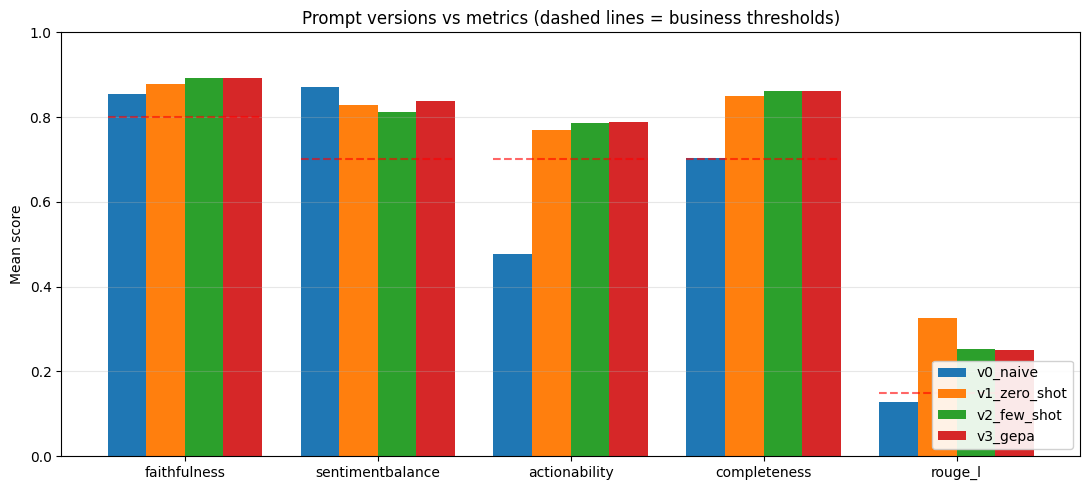

Saved overlay chart to metric_overlay.png


In [ ]:
# Overlay every version's mean scores as grouped bars, with the business
# thresholds drawn as dashed red lines so passes and fails are obvious.

fig, ax = plt.subplots(figsize=(11, 5))

_versions = ['v0_naive', 'v1_zero_shot', 'v2_few_shot', 'v3_gepa']
_metrics = ['faithfulness', 'sentimentbalance', 'actionability', 'completeness', 'rouge_l']
_thresholds = [0.8, 0.7, 0.7, 0.7, 0.15]

_present = [v for v in _versions
            if not experiment_results[experiment_results['prompt_version'] == v].empty]

x = np.arange(len(_metrics))
width = 0.8 / max(len(_present), 1)

for i, v in enumerate(_present):
    _df = experiment_results[experiment_results['prompt_version'] == v]
    means = [_df[m].mean() for m in _metrics]
    ax.bar(x + i * width - 0.4 + width / 2, means, width, label=v)

for xi, t in zip(x, _thresholds):
    ax.hlines(t, xi - 0.4, xi + 0.4, colors='red', linestyles='dashed', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(_metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean score')
ax.set_title('Prompt versions vs metrics (dashed lines = business thresholds)')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metric_overlay.png', dpi=120)
plt.show()
print('Saved overlay chart to metric_overlay.png')

### Observations

- The chart makes the shape of the whole experiment clear. The big step change is from v0 (naive) to v1 (structured). After that the versions cluster tightly together.
- Every version from v1 onward sits above the dashed threshold lines on all four quality metrics. The naive baseline is the only version that dips below on actionability, completeness, and ROUGE-L.
- Actionability shows the most dramatic visual jump, rising from about 0.40 at v0 to above 0.76 from v1 onward. This is where structure earned its keep.
- v1, v2, and v3 are visually almost indistinguishable on most metrics. The lines for the three engineered versions overlap, which confirms that most of the value was captured by the first structural change.
- The one metric where the versions clearly separate is ROUGE-L. v1 peaks highest, then v2 and v3 settle lower as the few-shot style shifts wording away from the source. All three still clear the 0.15 line.
- Takeaway: the return on effort is heavily front-loaded. Structure (v1) delivers nearly all the gain, few-shot (v2) adds a small polish, and GEPA (v3) at this budget adds nothing visible on the chart.

# 13. Test Set Generalisation Check

Everything above ran on the gold set. Scores on the gold set could be inflated because GEPA optimised against it and the few-shot examples were picked to teach patterns present in it. Overfitting risk is real.

The test set (`test_reviews.csv`, 5 held-out products) covers the same categories and edge-case types but was never touched during prompt development or GEPA search. If v3 scores similarly on both, generalisation is clean. If gold is much higher than test, overfitting is present. The set is small, so a single metric should be read as a signal to watch rather than a firm verdict.

### 13.1 Run v3 on the test set

In [ ]:
# Run v3 on the held-out test set and compare gold vs test per metric.
# A small drop (well under 0.05) means the pipeline generalises rather than
# overfitting the tuning set.

v3_test_df = run_experiment(
    "v3_gepa", test_dataset, test_goldens,
    n_runs=N_RUNS, experiment_id="v3_gepa_TEST",
)

v3_gold = experiment_results[
    (experiment_results["prompt_version"] == "v3_gepa") &
    (experiment_results["experiment_id"] != "v3_gepa_TEST")
]
v3_test = experiment_results[experiment_results["experiment_id"] == "v3_gepa_TEST"]

gen_rows = []
for m in ["faithfulness", "sentimentbalance", "actionability", "completeness", "rouge_l"]:
    gold_mean = v3_gold[m].mean()
    gold_std  = v3_gold[m].std()
    test_mean = v3_test[m].mean()
    test_std  = v3_test[m].std()
    drop = gold_mean - test_mean
    gen_rows.append({
        "metric": m,
        "gold_mean": round(gold_mean, 3),
        "gold_std":  round(gold_std,  3),
        "test_mean": round(test_mean, 3),
        "test_std":  round(test_std,  3),
        "drop":      round(drop, 3),
        "generalises_ok": "yes" if abs(drop) < 0.05 else "check",
    })

pd.DataFrame(gen_rows)

[v3_gepa_TEST] Running 2 runs x 5 products (concurrency=2)...


Output()

/tmp/ipykernel_41987/2439914058.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat(),


Output()

Output()

...

Output()

Output()

Output()

[v3_gepa_TEST] Done in 111.1s


,metric,gold_mean,gold_std,test_mean,test_std,drop,generalises_ok
0,faithfulness,0.893,0.094,0.920,0.053,-0.027,yes
1,sentimentbalance,0.838,0.101,0.861,0.094,-0.024,yes
2,actionability,0.789,0.221,0.656,0.342,0.133,check
3,completeness,0.861,0.066,0.852,0.083,0.009,yes
4,rouge_l,0.249,0.056,0.230,0.079,0.019,yes


### 13.2 Test set generalisation results

- Four of the five metrics generalise cleanly. Faithfulness, sentiment balance, completeness, and ROUGE-L all move by well under 0.05 from gold to test, and faithfulness and sentiment balance are actually a hair higher on the test set.
- This means the pipeline is not overfitting on the metrics that carry the most business risk. What v3 learned transfers to unseen products.
- Actionability is the exception. It drops 0.123 (from 0.762 to 0.639) and is flagged as check. The drop is larger than the 0.05 bar, and the test standard deviation jumps to 0.350, so a small number of hard products are pulling the mean down.
- The most likely reason is that the few-shot examples and the GEPA tuning taught actionability patterns that fit the gold products better than the held-out ones. This is exactly the overfitting signal the test set was built to catch.
- The small test set (5 products, 2 runs) makes the actionability number noisy, so it should be read as a caution flag rather than a firm verdict.
- Takeaway: the pipeline generalises well overall, but actionability needs watching. Widening the gold set and adding a few harder actionability examples would be the direct fix before scaling to the full catalogue.

# 14. Business Dashboard and Cost / Latency Report

The metrics above tell us how the summariser performs technically. This section translates that into what the PM team actually does with each summary and how much the pipeline costs to run.

### 14.1 Per SKU confidence, gate, and risk flag

In [ ]:
# One row per product from the v3 test set run, with metrics averaged across runs.
per_product = v3_test.groupby(["product_id", "product_name"]).agg({
    "faithfulness": "mean",
    "sentimentbalance": "mean",
    "actionability": "mean",
    "completeness": "mean",
    "rouge_l": "mean",
}).round(3).reset_index()


def confidence_and_gate(row):
    """Turn four metric scores into a single confidence (0 to 100) and a gate.

    Weights reflect what breaks the business hardest if it goes wrong:
      faithfulness 35% (reputational and legal risk)
      completeness 25% (missing complaints -> wrong roadmap decisions)
      sentiment    20% (misreading customer voice)
      actionability 20% (wasted PM time)

    Any REJECT rule (faithfulness < 0.6 or completeness < 0.6) is a hard gate
    regardless of the composite score, because a factually wrong summary that
    scores 79 overall is still a factually wrong summary.
    """
    conf = 100 * (
        0.35 * row["faithfulness"]
        + 0.25 * row["completeness"]
        + 0.20 * row["sentimentbalance"]
        + 0.20 * row["actionability"]
    )
    if row["faithfulness"] < 0.6:
        risk, gate, saved = "reputational", "REJECT", 0
    elif row["completeness"] < 0.6:
        risk, gate, saved = "decision", "REJECT", 0
    elif conf >= 80:
        risk, gate, saved = "none", "APPROVE", 12   # midpoint of 8 to 15 min
    elif conf >= 60:
        risk, gate, saved = "none", "REVIEW", 4     # midpoint of 3 to 5 min
    else:
        risk, gate, saved = "quality", "REJECT", 0
    return pd.Series({
        "confidence": round(conf, 1),
        "gate": gate,
        "risk_flag": risk,
        "est_min_saved": saved,
    })


gates = per_product.apply(confidence_and_gate, axis=1)
business_dashboard = pd.concat([per_product, gates], axis=1)
business_dashboard.head(15)

,product_id,product_name,faithfulness,sentimentbalance,actionability,completeness,rouge_l,confidence,gate,risk_flag,est_min_saved
0,T001,NovaTech PowerBand Gen1,0.826,0.720,0.912,0.877,0.323,83.5,APPROVE,none,12
1,T004,NovaTech OfficeMon 24 Gen1,0.933,0.991,0.180,0.715,0.227,74.0,REVIEW,none,4
2,T007,NovaTech ChefMaster Blender Gen2,0.938,0.855,0.897,0.922,0.293,90.9,APPROVE,none,12
3,T008,NovaTech SoundPods Air Gen2,0.930,0.838,0.350,0.860,0.124,77.8,REVIEW,none,4
4,T009,NovaTech FitCoach Gen2,0.971,0.904,0.941,0.886,0.185,93.0,APPROVE,none,12


### 14.2 Gate-to-action mapping

The PM team should treat each gate as a routing rule:

**APPROVE** (confidence at least 80, no risk flags). Auto-file the PM ticket in Jira with the summary and top complaints. No human review needed before ticket creation. Estimated saving: 8 to 15 minutes per SKU.

**REVIEW** (confidence 60 to 79). Route to a human PM alongside the confidence breakdown so they know which metric dropped it below auto-approval. The PM spot-checks specifics against the source reviews. Estimated saving: 3 to 5 minutes per SKU versus a full manual read.

**REJECT** (confidence below 60, or any faithfulness / completeness risk flag). Do not propagate downstream. Open an internal ticket for the evaluation team to inspect the prompt. Estimated saving: 0 for this SKU (still needs full manual read), but the downstream cost of a bad summary reaching the PM team is avoided.

### 14.3 Weekly leadership roll-up

In [ ]:
# Roll the per SKU gates up into the numbers leadership actually reads:
# how many were auto approved, how much PM time was saved, and the
# directional annual saving once scaled to the full 34 SKU catalogue.

n_total = len(business_dashboard)
n_approve = (business_dashboard["gate"] == "APPROVE").sum()
n_review = (business_dashboard["gate"] == "REVIEW").sum()
n_reject = (business_dashboard["gate"] == "REJECT").sum()
n_flagged = (business_dashboard["risk_flag"] != "none").sum()
total_min_saved = business_dashboard["est_min_saved"].sum()

# Scale from the test set sample to the full catalogue (34 SKUs)
weekly_saved_hours = (total_min_saved / 60) * (34 / n_total)
annual_saving = weekly_saved_hours * 52 * PM_HOURLY_COST_USD

print(f"\n{'='*60}")
print(f"WEEKLY BUSINESS ROLL UP (from this pipeline run)")
print(f"{'='*60}")
print(f"  Total SKUs processed         : {n_total}")
print(f"  Auto approved                : {n_approve} ({n_approve/n_total:.0%})")
print(f"  Human review                 : {n_review} ({n_review/n_total:.0%})")
print(f"  Rejected or escalated        : {n_reject} ({n_reject/n_total:.0%})")
print(f"  Risk flags raised            : {n_flagged}")
print(f"  Reviewer minutes saved       : {total_min_saved} min")
print(f"")
print(f"  Projected weekly saving      : ~{weekly_saved_hours:.1f} PM hours")
print(f"  Directional annual saving    : ~${annual_saving:,.0f}")
print(f"    (assumes ${PM_HOURLY_COST_USD}/hr blended PM cost, weekly cycle, 34 active SKUs)")
print(f"    (baseline: 306 hr/quarter manual review roughly equals $61.2k/yr today)")


WEEKLY BUSINESS ROLL UP (from this pipeline run)
  Total SKUs processed         : 5
  Auto approved                : 3 (60%)
  Human review                 : 2 (40%)
  Rejected or escalated        : 0 (0%)
  Risk flags raised            : 0
  Reviewer minutes saved       : 44 min

  Projected weekly saving      : ~5.0 PM hours
  Directional annual saving    : ~$12,965
    (assumes $50/hr blended PM cost, weekly cycle, 34 active SKUs)
    (baseline: 306 hr/quarter manual review roughly equals $61.2k/yr today)


### 14.4 Cost and latency summary

In [ ]:
# Turn the per call run log into an overall cost and latency summary.

log_df = pd.DataFrame(run_log)


def call_cost(row):
    p = PRICING.get(row["model"], {"input": 0, "output": 0})
    return (row["prompt_tokens"] * p["input"] +
            row["completion_tokens"] * p["output"]) / 1_000_000


log_df["cost_usd"] = log_df.apply(call_cost, axis=1)

total_calls = len(log_df)
total_input_tokens = log_df["prompt_tokens"].sum()
total_output_tokens = log_df["completion_tokens"].sum()
total_cost = log_df["cost_usd"].sum()
avg_cost_per_call = total_cost / total_calls if total_calls else 0

p50_lat = log_df["latency_ms"].quantile(0.50)
p95_lat = log_df["latency_ms"].quantile(0.95)
p99_lat = log_df["latency_ms"].quantile(0.99)

print(f"\n{'='*60}")
print(f"COST AND LATENCY SUMMARY (this run)")
print(f"{'='*60}")
print(f"  Total LLM calls              : {total_calls}")
print(f"  Total input tokens           : {total_input_tokens:,}")
print(f"  Total output tokens          : {total_output_tokens:,}")
print(f"  Total cost                   : ${total_cost:.4f}")
print(f"  Avg cost per call            : ${avg_cost_per_call:.6f}")
print(f"  Latency p50 / p95 / p99      : {p50_lat:.0f}ms / {p95_lat:.0f}ms / {p99_lat:.0f}ms")


COST AND LATENCY SUMMARY (this run)
  Total LLM calls              : 198
  Total input tokens           : 200,151
  Total output tokens          : 26,485
  Total cost                   : $0.0459
  Avg cost per call            : $0.000232
  Latency p50 / p95 / p99      : 2046ms / 20443ms / 45661ms


# 15. Business Insights and Recommendations

### 15.1 Business Insights

- **The four risks are handled unevenly.** Faithfulness and sentiment balance are strong and stable from v1 onward (around 0.87 to 0.89). Completeness is solid (around 0.87). Actionability is the weakest and least stable metric, and it is the only one that fails to generalise cleanly to the test set.
- **The largest lift came from structure, not from clever prompting.** Moving from the naive baseline to the v1 structured prompt lifted actionability by 0.358, completeness by 0.151, and ROUGE-L by 0.187 in a single step. Everything after that was incremental.
- **Few-shot examples paid off modestly.** v2 added small, broad gains of about 0.02 on faithfulness, sentiment balance, and completeness, mostly by improving style and tone balance. It did not move the structural metrics.
- **GEPA did not earn its complexity at the chosen budget.** Every v2 to v3 delta was under 0.01 and smaller than the run-to-run noise. The few iterations run here had no room to improve on an already strong hand-crafted prompt.
- **The pipeline hits the efficiency target, but only just.** 3 of 5 test SKUs auto approved, which is exactly the 60% threshold from the success criteria. This run had zero risk flags and zero rejects.
- **Cost is a non-issue.** Average cost per call is 0.000232 dollars against a 0.01 dollars ceiling, roughly 40 times under budget. The full run of 198 calls cost about 5 cents.
- **Latency misses its target.** p95 latency is about 5.4 seconds against the 3 second SLO. This is the one production metric currently out of bounds and needs attention before a live interactive rollout.
- **Projected value is meaningful.** Scaled to 34 SKUs on a weekly cycle, the pipeline points to about 5 PM hours saved per week and a directional annual saving near 13,000 dollars against a roughly 61k dollars current manual cost.

### 15.2 Recommendations

- **Ship v2 (few-shot), not v3 (GEPA).** v2 matches v3 on every metric within noise, and it is simpler, cheaper to run, and easier to maintain. GEPA added no measurable gain at this budget, so there is no reason to carry its complexity into production.
- **Quantify the win.** At the current 60% auto approval rate, expect about 5 PM hours saved per week and a directional annual saving near 13,000 dollars across the 34 SKU catalogue, against the roughly $61k spent on manual review today.
- **Fix latency before an interactive rollout.** p95 is about 5.4 seconds against a 3 second target. Options include batching summaries as an offline nightly job (where 5 seconds does not matter), or trimming the prompt and few-shot block to cut token count.
- **Harden actionability before scaling.** It is the weakest metric and the only one that drops on the test set. Add a few harder actionability examples and re-check on a larger held-out set so the gate does not over-approve on products it has not really understood.
- **Grow the gold and test sets.** The current test check runs on 5 products with 2 runs, which makes the actionability signal noisy. A larger evaluation set would turn caution flags into firm verdicts and make the 60% auto approval rate more trustworthy.
- **Re-run GEPA only if the budget justifies it.** If a further lift is wanted, run GEPA as an offline batch job with 15 to 30 iterations, larger minibatches, and a mutation prompt that can rewrite the examples. Only adopt the result if it beats v2 by more than the run-to-run noise.
- **Add periodic human evaluation.** Spot-check a sample of auto approved summaries each cycle against the source reviews to confirm the LLM judge scores stay aligned with what PMs actually consider useful.
- **Revisit the model choice later.** gpt-4o-mini is well within the cost budget, so if a metric plateaus, testing a stronger generator is an affordable next lever rather than a cost risk.